# IMPORT LIBRARY

In [223]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# LOAD DATASET

## IMPORT ALL DATASETS FROM CSV

In [224]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
test_target = pd.read_csv('gender_submission.csv')


## SHOW ALL DATASETS INFO

In [225]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [226]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    str    
 3   Sex          418 non-null    str    
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    str    
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     str    
 10  Embarked     418 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 36.1 KB


In [227]:
test_target.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   PassengerId  418 non-null    int64
 1   Survived     418 non-null    int64
dtypes: int64(2)
memory usage: 6.7 KB


## MERGE ALL DATASETS TO DATAFRAME

In [228]:
y = pd.concat([train['Survived'], test_target['Survived']])

train = train.drop('Survived', axis=1)
x = pd.concat([train, test])

df = pd.concat([x, y], axis=1)
df.info()

<class 'pandas.DataFrame'>
Index: 1309 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Pclass       1309 non-null   int64  
 2   Name         1309 non-null   str    
 3   Sex          1309 non-null   str    
 4   Age          1046 non-null   float64
 5   SibSp        1309 non-null   int64  
 6   Parch        1309 non-null   int64  
 7   Ticket       1309 non-null   str    
 8   Fare         1308 non-null   float64
 9   Cabin        295 non-null    str    
 10  Embarked     1307 non-null   str    
 11  Survived     1309 non-null   int64  
dtypes: float64(2), int64(5), str(5)
memory usage: 132.9 KB


# PREPROCESSING DATA

## DROP IDENTIFIER FEATURE

In [229]:
df = df.drop(['PassengerId', 'Name', 'Ticket'], axis=1)
df.info()

<class 'pandas.DataFrame'>
Index: 1309 entries, 0 to 417
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    1309 non-null   int64  
 1   Sex       1309 non-null   str    
 2   Age       1046 non-null   float64
 3   SibSp     1309 non-null   int64  
 4   Parch     1309 non-null   int64  
 5   Fare      1308 non-null   float64
 6   Cabin     295 non-null    str    
 7   Embarked  1307 non-null   str    
 8   Survived  1309 non-null   int64  
dtypes: float64(2), int64(4), str(3)
memory usage: 102.3 KB


## HANDLE MISSING VALUE


In [230]:
# CHECK MISSING VALUES
df.isnull().sum()

Pclass         0
Sex            0
Age          263
SibSp          0
Parch          0
Fare           1
Cabin       1014
Embarked       2
Survived       0
dtype: int64

In [231]:
# HANDLE MISSING VALUES

# MENGHAPUS KOLOM DENGAN MISSING VALUE DI ATAS 25%  
df = df.drop('Cabin', axis=1)

# UNTUK KOLOM DENGAN MISSING VALUE DI BAWAH 25%

# UNTUK DATA NUMERIK, ISI MISSING VALUES DENGAN MEDIAN PADA KOLOM TERSEBUT
numerical_cols = df.select_dtypes(include='number').columns
df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].median())

# UNTUK DATA KATEGORIKAL, ISI MISSING VALUES DENGAN MODUS PADA KOLOM TERSEBUT
categorical_cols = df.select_dtypes(include='object').columns
df[categorical_cols] = df[categorical_cols].fillna(df[categorical_cols].mode().iloc[0])

df.info()

<class 'pandas.DataFrame'>
Index: 1309 entries, 0 to 417
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    1309 non-null   int64  
 1   Sex       1309 non-null   str    
 2   Age       1309 non-null   float64
 3   SibSp     1309 non-null   int64  
 4   Parch     1309 non-null   int64  
 5   Fare      1309 non-null   float64
 6   Embarked  1309 non-null   str    
 7   Survived  1309 non-null   int64  
dtypes: float64(2), int64(4), str(2)
memory usage: 92.0 KB


C:\Users\tabiz\AppData\Local\Temp\ipykernel_35592\2545923832.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns


## STANDARDIZATION

In [232]:
# BEFORE STANDARDIZATION
df.describe()

,Pclass,Age,SibSp,Parch,Fare,Survived
count,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000
mean,2.294882,29.503186,0.498854,0.385027,33.281086,0.377387
std,0.837836,12.905241,1.041658,0.865560,51.741500,0.484918
min,1.000000,0.170000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,22.000000,0.000000,0.000000,7.895800,0.000000
50%,3.000000,28.000000,0.000000,0.000000,14.454200,0.000000
75%,3.000000,35.000000,1.000000,0.000000,31.275000,1.000000
max,3.000000,80.000000,8.000000,9.000000,512.329200,1.000000


In [233]:
# SCALING
scaler = StandardScaler()

df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

In [234]:
# AFTER STANDARDIZATION
df.describe()

,Pclass,Age,SibSp,Parch,Fare,Survived
count,1.309000e+03,1.309000e+03,1.309000e+03,1.309000e+03,1.309000e+03,1.309000e+03
mean,-2.062691e-16,3.358658e-17,-1.628440e-17,1.730218e-17,-2.442660e-17,4.071100e-17
std,1.000382e+00,1.000382e+00,1.000382e+00,1.000382e+00,1.000382e+00,1.000382e+00
min,-1.546098e+00,-2.273836e+00,-4.790868e-01,-4.449995e-01,-6.434642e-01,-7.785467e-01
25%,-3.520907e-01,-5.816283e-01,-4.790868e-01,-4.449995e-01,-4.908050e-01,-7.785467e-01
50%,8.419164e-01,-1.165232e-01,-4.790868e-01,-4.449995e-01,-3.640034e-01,-7.785467e-01
75%,8.419164e-01,4.260994e-01,4.812878e-01,-4.449995e-01,-3.878613e-02,1.284444e+00
max,8.419164e-01,3.914388e+00,7.203909e+00,9.956864e+00,9.262028e+00,1.284444e+00


## DATA TYPE CONVERSION

In [235]:
# BEFORE ENCODING
df.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Survived
0,0.841916,male,-0.581628,0.481288,-0.445,-0.503291,S,-0.778547
1,-1.546098,female,0.658652,0.481288,-0.445,0.734744,C,1.284444
2,0.841916,female,-0.271558,-0.479087,-0.445,-0.490240,S,1.284444
3,-1.546098,female,0.426099,0.481288,-0.445,0.383183,S,1.284444
4,0.841916,male,0.426099,-0.479087,-0.445,-0.487824,S,-0.778547


In [236]:
label_encoder = LabelEncoder()

for col in categorical_cols:
    df[col] = label_encoder.fit_transform(df[col])

# AFTER ENCODING
df.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Survived
0,0.841916,1,-0.581628,0.481288,-0.445,-0.503291,2,-0.778547
1,-1.546098,0,0.658652,0.481288,-0.445,0.734744,0,1.284444
2,0.841916,0,-0.271558,-0.479087,-0.445,-0.490240,2,1.284444
3,-1.546098,0,0.426099,0.481288,-0.445,0.383183,2,1.284444
4,0.841916,1,0.426099,-0.479087,-0.445,-0.487824,2,-0.778547


## DATA SPLIT

In [237]:
x = df.drop('Survived', axis=1)
y = df['Survived'].astype(int)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print("Jumlah Data:",len(x))
print("Jumlah Data Train:",len(x_train))
print("Jumlah Data Test:",len(x_test))

Jumlah Data: 1309
Jumlah Data Train: 1047
Jumlah Data Test: 262


# MODEL TRAINING

In [238]:
model = DecisionTreeClassifier().fit(x_train, y_train)

# MODEL EVALUATION

## CONFUSION MATRIX

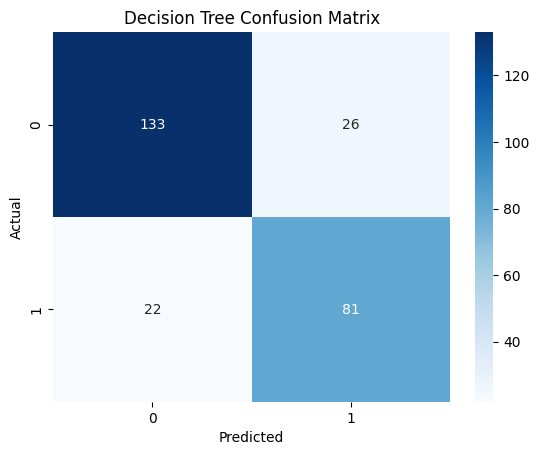

In [239]:
y_pred = model.predict(x_test)

cm = confusion_matrix(y_test, y_pred)

plt.Figure(figsize=(10, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")
plt.show()

## EVALUATION SCORE

In [240]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Decision Tree Model Evaluation Score\n")

print("Accuracy: ", accuracy)
print("Precision: ", precision)
print("Recall: ", recall)
print("F1-Score: ", f1)

Decision Tree Model Evaluation Score

Accuracy:  0.816793893129771
Precision:  0.7570093457943925
Recall:  0.7864077669902912
F1-Score:  0.7714285714285715
